In [8]:
import pandas as pd
import numpy as np
import zipfile
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator



In [ ]:
# =============================================================
# PROYECTO COMPLETO: Detección de lunares malignos (CNN + ABCDE)
# CNN entrenada + compensación por desbalance + augmentación
# =============================================================

import os
import zipfile
from PIL import Image
import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, f1_score
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     BatchNormalization, GlobalAveragePooling2D, concatenate)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -------------------------
# 1. CONFIGURACIÓN
# -------------------------
CSV_PATH = r"D:\Lunar\ham10000.csv"
ZIP_PATH = r"D:\descargas\Download\ISIC-images.zip"
IMG_SIZE = (128, 128)
EPOCHS = 40
BATCH_SIZE = 32
RANDOM_STATE = 42

# -------------------------
# 2. FUNCIONES ABCDE
# -------------------------
def calc_asymmetry(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, IMG_SIZE)
    h, w = gray.shape
    left, right = gray[:, :w//2], gray[:, w//2:]
    if right.shape[1] != left.shape[1]:
        right = cv2.resize(right, (left.shape[1], left.shape[0]))
    right_flipped = cv2.flip(right, 1)
    diff_h = np.mean(np.abs(left - right_flipped))
    top, bottom = gray[:h//2, :], gray[h//2:, :]
    if bottom.shape[0] != top.shape[0]:
        bottom = cv2.resize(bottom, (top.shape[1], top.shape[0]))
    bottom_flipped = cv2.flip(bottom, 0)
    diff_v = np.mean(np.abs(top - bottom_flipped))
    return (diff_h + diff_v) / 2.0

def calc_border_irregularity(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray = (gray*255).astype(np.uint8)
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0.0
    contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    if area <= 1e-6:
        return 0.0
    return (perimeter ** 2) / (4 * np.pi * area)

def calc_color_features(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    var_h, var_s, var_v = np.var(hsv[:,:,0]), np.var(hsv[:,:,1]), np.var(hsv[:,:,2])
    pixels = hsv.reshape(-1, 3).astype(np.float32)
    K = 3
    try:
        _, labels, _ = cv2.kmeans(pixels, K, None,
                                  (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0),
                                  10, cv2.KMEANS_RANDOM_CENTERS)
        num_colors = len(np.unique(labels))
    except Exception:
        num_colors = 1
    return (var_h + var_s + var_v) / 3, num_colors

def calc_diameter(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray = (gray*255).astype(np.uint8)
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    area = np.sum(mask > 0)
    return 2 * np.sqrt(area / np.pi) if area > 0 else 0

def extract_ABCDE_features(image):
    A = calc_asymmetry(image)
    B = calc_border_irregularity(image)
    C_var, C_colors = calc_color_features(image)
    D = calc_diameter(image)
    return [A, B, C_var, C_colors, D]

def extract_ABCDE_dataset(images):
    feats = [extract_ABCDE_features(img) for img in images]
    return np.array(feats, dtype=float)

# -------------------------
# 3. CARGA DE DATOS
# -------------------------
df = pd.read_csv(CSV_PATH)
df['label'] = df['diagnosis_1'].apply(lambda x: 0 if x.lower() == 'benign' else 1)

def load_image_from_zip(zip_ref, img_name, size=IMG_SIZE):
    img_file = img_name + ".jpg"
    if img_file not in zip_ref.namelist():
        raise KeyError(f"{img_file} no encontrado en el ZIP.")
    with zip_ref.open(img_file) as f:
        img = Image.open(f).convert("RGB")
        img = img.resize(size)
        return np.array(img) / 255.0

images, labels = [], []
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    for i, row in enumerate(df.itertuples(), 1):
        try:
            img = load_image_from_zip(zip_ref, row.isic_id)
            images.append(img)
            labels.append(row.label)
        except KeyError:
            continue
        if i % 500 == 0:
            print(f"  -> {i}/{len(df)} imágenes cargadas...")

X = np.array(images, dtype='float32')
y = np.array(labels, dtype=int)
print(f"\n✅ Dataset cargado: X={X.shape}, y={y.shape}")

# -------------------------
# 4. DIVISIÓN DEL CONJUNTO
# -------------------------
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=RANDOM_STATE)

# -------------------------
# 5. EXTRACCIÓN Y ESCALADO DE FEATURES ABCDE
# -------------------------
ABCDE_train = extract_ABCDE_dataset((X_train*255).astype(np.uint8))
ABCDE_val = extract_ABCDE_dataset((X_val*255).astype(np.uint8))
ABCDE_test = extract_ABCDE_dataset((X_test*255).astype(np.uint8))

scaler = StandardScaler()
ABCDE_train_s = scaler.fit_transform(ABCDE_train)
ABCDE_val_s = scaler.transform(ABCDE_val)
ABCDE_test_s = scaler.transform(ABCDE_test)

# -------------------------
# 6. DATA AUGMENTATION
# -------------------------
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,
    zoom_range=0.1
)

# -------------------------
# 7. MODELO CNN + ABCDE
# -------------------------
def build_cnn(input_shape=(128,128,3)):
    inp = Input(shape=input_shape)
    x = Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2)(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2)(x)
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    return Model(inp, x, name="cnn_backbone")

cnn = build_cnn(IMG_SIZE+(3,))
img_input = Input(shape=IMG_SIZE+(3,), name="image_input")
abcde_input = Input(shape=(ABCDE_train_s.shape[1],), name="abcde_input")
cnn_features = cnn(img_input)
x = concatenate([cnn_features, abcde_input])
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)
model = Model([img_input, abcde_input], out)
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='AUC')])
model.summary()

# -------------------------
# 8. PESOS DE CLASE
# -------------------------
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
print("Pesos de clase:", class_weights)





  -> 500/11720 imágenes cargadas...
  -> 1000/11720 imágenes cargadas...
  -> 1500/11720 imágenes cargadas...
  -> 2000/11720 imágenes cargadas...
  -> 2500/11720 imágenes cargadas...
  -> 3000/11720 imágenes cargadas...
  -> 3500/11720 imágenes cargadas...
  -> 4000/11720 imágenes cargadas...
  -> 4500/11720 imágenes cargadas...
  -> 5000/11720 imágenes cargadas...
  -> 5500/11720 imágenes cargadas...
  -> 6000/11720 imágenes cargadas...
  -> 6500/11720 imágenes cargadas...
  -> 7000/11720 imágenes cargadas...
  -> 7500/11720 imágenes cargadas...
  -> 8000/11720 imágenes cargadas...
  -> 8500/11720 imágenes cargadas...
  -> 9000/11720 imágenes cargadas...
  -> 9500/11720 imágenes cargadas...
  -> 10000/11720 imágenes cargadas...
  -> 10500/11720 imágenes cargadas...
  -> 11000/11720 imágenes cargadas...
  -> 11500/11720 imágenes cargadas...

✅ Dataset cargado: X=(11720, 128, 128, 3), y=(11720,)
Model: "model_5"
__________________________________________________________________________

ValueError: The following argument(s) are not supported with the native Keras format: ['options']

74/74 [==============================] - 4s 58ms/step

✅ Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.48      0.65      1883
           1       0.32      0.99      0.48       461

    accuracy                           0.58      2344
   macro avg       0.66      0.73      0.56      2344
weighted avg       0.86      0.58      0.61      2344


✅ Matriz de confusión (counts):
             Pred 0  Pred 1
Benigno(0)     900     983
Maligno(1)       5     456

✅ Matriz de confusión (% por fila):
 [[0.4779607  0.5220393 ]
 [0.01084599 0.98915401]]

✅ AUC: 0.8413


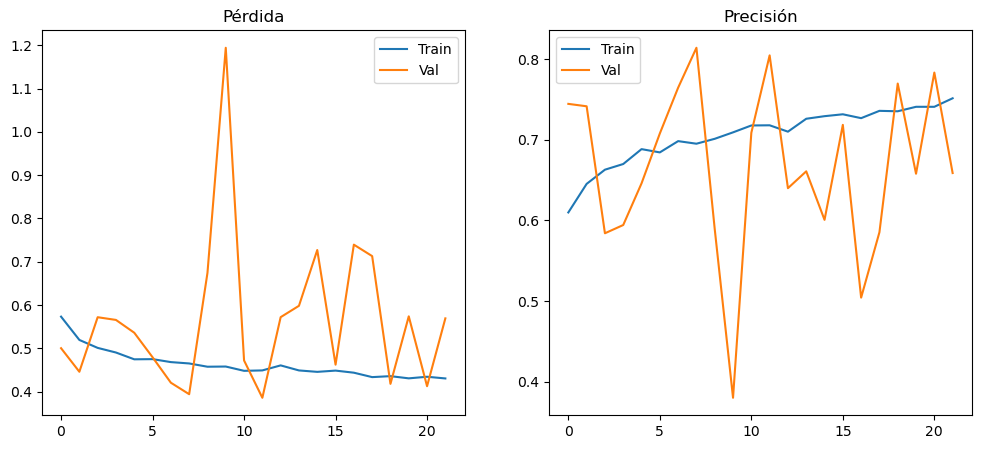

✅ Modelo y scaler guardados correctamente.


c:\Users\M650C\anaconda3\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [23]:
y_pred_proba = model.predict([X_test, ABCDE_test])
y_pred = (y_pred_proba > 0.2).astype(int)

print("\n✅ Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Benigno(0)', 'Maligno(1)'], columns=['Pred 0', 'Pred 1'])
print("\n✅ Matriz de confusión (counts):\n", cm_df)
print("\n✅ Matriz de confusión (% por fila):\n", cm / cm.sum(axis=1, keepdims=True))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n✅ AUC: {roc_auc:.4f}")

# -------------------------
# 10. CURVAS
# -------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Pérdida'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Precisión'); plt.legend()
plt.show()

# -------------------------
# 11. GUARDADO DE MODELO Y SCALER
# -------------------------
model.save("modelo_cnn_abcd_final.h5")
joblib.dump(scaler, "scaler_abcd.pkl")
print("✅ Modelo y scaler guardados correctamente.")

Epoch 1/40
257/257 [==============================] - 84s 326ms/step - loss: 0.5036 - accuracy: 0.6590 - AUC: 0.8116 - val_loss: 0.4656 - val_accuracy: 0.6913 - val_AUC: 0.8078 - lr: 1.0000e-04
Epoch 2/40


c:\Users\M650C\anaconda3\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


257/257 [==============================] - 83s 323ms/step - loss: 0.4924 - accuracy: 0.6735 - AUC: 0.8203 - val_loss: 0.5342 - val_accuracy: 0.6390 - val_AUC: 0.8471 - lr: 1.0000e-04
Epoch 3/40
257/257 [==============================] - 84s 326ms/step - loss: 0.4785 - accuracy: 0.6949 - AUC: 0.8340 - val_loss: 0.4809 - val_accuracy: 0.7260 - val_AUC: 0.8469 - lr: 1.0000e-04
Epoch 4/40
257/257 [==============================] - 85s 329ms/step - loss: 0.4653 - accuracy: 0.7088 - AUC: 0.8432 - val_loss: 0.4233 - val_accuracy: 0.8044 - val_AUC: 0.8031 - lr: 1.0000e-04
Epoch 5/40
257/257 [==============================] - 84s 327ms/step - loss: 0.4641 - accuracy: 0.7049 - AUC: 0.8453 - val_loss: 0.4297 - val_accuracy: 0.7464 - val_AUC: 0.8132 - lr: 1.0000e-04
Epoch 6/40
257/257 [==============================] - 84s 328ms/step - loss: 0.4547 - accuracy: 0.7232 - AUC: 0.8557 - val_loss: 1.0701 - val_accuracy: 0.3781 - val_AUC: 0.7986 - lr: 1.0000e-04
Epoch 7/40
257/257 [=====================

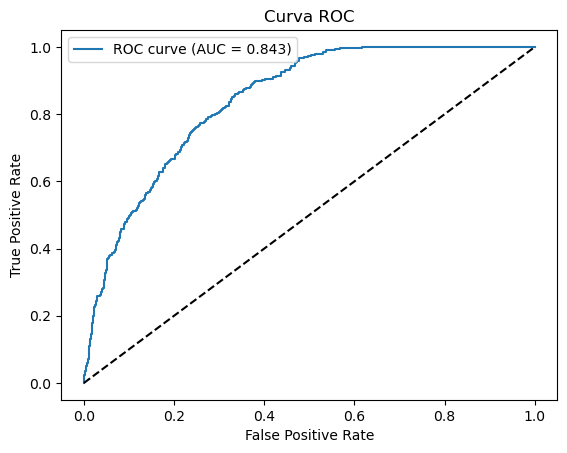

In [25]:
# -------------------------
# 9. CALLBACKS
# -------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('modelo_cnn_abcd_best.h5', save_best_only=True)
]

# -------------------------
# 10. ENTRENAMIENTO
# -------------------------
history = model.fit(
    datagen.flow([X_train, ABCDE_train_s], y_train, batch_size=BATCH_SIZE),
    validation_data=([X_val, ABCDE_val_s], y_val),
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# -------------------------
# 11. EVALUACIÓN FINAL
# -------------------------
y_pred_prob = model.predict([X_test, ABCDE_test_s])
thresholds = np.arange(0.1,0.9,0.01)
f1_scores = [f1_score(y_test, (y_pred_prob>t).astype(int), pos_label=1) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"\n✅ Threshold óptimo (max F1 maligno): {best_threshold:.2f}")

y_pred_final = (y_pred_prob > best_threshold).astype(int)

report = classification_report(y_test, y_pred_final, output_dict=True, digits=4)
roc_auc_final = roc_auc_score(y_test, y_pred_prob)
cm_final = confusion_matrix(y_test, y_pred_final)
cm_norm_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

metrics_table = pd.DataFrame({
    "Clase": ["Benigno(0)", "Maligno(1)", "Macro Avg", "Weighted Avg"],
    "Precision": [report['0']['precision'], report['1']['precision'], report['macro avg']['precision'], report['weighted avg']['precision']],
    "Recall": [report['0']['recall'], report['1']['recall'], report['macro avg']['recall'], report['weighted avg']['recall']],
    "F1-score": [report['0']['f1-score'], report['1']['f1-score'], report['macro avg']['f1-score'], report['weighted avg']['f1-score']],
    "Support": [report['0']['support'], report['1']['support'], report['macro avg']['support'], report['weighted avg']['support']]
})

print("\n📊 Tabla de métricas resumida (threshold óptimo):")
print(metrics_table)
print("\n✅ Matriz de confusión (counts):\n", cm_final)
print("\n✅ Matriz de confusión (% por fila):\n", cm_norm_final)
print(f"\n✅ AUC: {roc_auc_final:.4f}")

# -------------------------
# 12. CURVA ROC
# -------------------------
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_final:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

55/55 [==============================] - 4s 81ms/step

✅ Threshold óptimo (max F1 maligno): 0.47

📊 Tabla de métricas resumida (threshold óptimo):
          Clase  Precision    Recall  F1-score  Support
0    Benigno(0)   0.972046  0.541785  0.695771   1412.0
1    Maligno(1)   0.333677  0.936416  0.492027    346.0
2     Macro Avg   0.652861  0.739100  0.593899   1758.0
3  Weighted Avg   0.846405  0.619454  0.655671   1758.0

✅ Matriz de confusión (counts):
 [[765 647]
 [ 22 324]]

✅ Matriz de confusión (% por fila):
 [[0.5417847  0.4582153 ]
 [0.06358382 0.93641618]]

✅ AUC: 0.8431


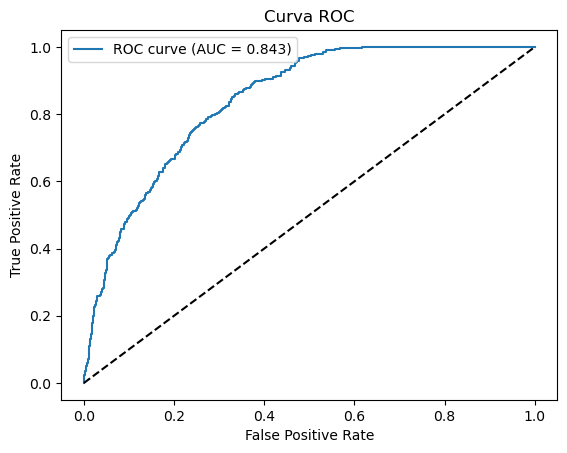

In [ ]:
# -------------------------
# 11. EVALUACIÓN FINAL
# -------------------------
y_pred_prob = model.predict([X_test, ABCDE_test_s])
thresholds = np.arange(0.1,0.9,0.01)
f1_scores = [f1_score(y_test, (y_pred_prob>t).astype(int), pos_label=1) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"\n✅ Threshold óptimo (max F1 maligno): {best_threshold:.2f}")

y_pred_final = (y_pred_prob > best_threshold).astype(int)

report = classification_report(y_test, y_pred_final, output_dict=True, digits=4)
roc_auc_final = roc_auc_score(y_test, y_pred_prob)
cm_final = confusion_matrix(y_test, y_pred_final)
cm_norm_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

metrics_table = pd.DataFrame({
    "Clase": ["Benigno(0)", "Maligno(1)", "Macro Avg", "Weighted Avg"],
    "Precision": [report['0']['precision'], report['1']['precision'], report['macro avg']['precision'], report['weighted avg']['precision']],
    "Recall": [report['0']['recall'], report['1']['recall'], report['macro avg']['recall'], report['weighted avg']['recall']],
    "F1-score": [report['0']['f1-score'], report['1']['f1-score'], report['macro avg']['f1-score'], report['weighted avg']['f1-score']],
    "Support": [report['0']['support'], report['1']['support'], report['macro avg']['support'], report['weighted avg']['support']]
})

print("\n📊 Tabla de métricas resumida (threshold óptimo):")
print(metrics_table)
print("\n✅ Matriz de confusión (counts):\n", cm_final)
print("\n✅ Matriz de confusión (% por fila):\n", cm_norm_final)
print(f"\n✅ AUC: {roc_auc_final:.4f}")

# -------------------------
# 12. CURVA ROC
# -------------------------
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_final:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

Epoch 1/40
101/101 [==============================] - ETA: 0s - loss: 0.4957 - accuracy: 0.7337 - AUC: 0.8152
Epoch 1: val_loss did not improve from 0.42417
101/101 [==============================] - 36s 342ms/step - loss: 0.4957 - accuracy: 0.7337 - AUC: 0.8152 - val_loss: 0.4822 - val_accuracy: 0.6839 - val_AUC: 0.8300 - lr: 2.5000e-05
Epoch 2/40
101/101 [==============================] - ETA: 0s - loss: 0.4863 - accuracy: 0.7409 - AUC: 0.8210
Epoch 2: val_loss did not improve from 0.42417
101/101 [==============================] - 34s 337ms/step - loss: 0.4863 - accuracy: 0.7409 - AUC: 0.8210 - val_loss: 0.4724 - val_accuracy: 0.7032 - val_AUC: 0.8436 - lr: 2.5000e-05
Epoch 3/40
101/101 [==============================] - ETA: 0s - loss: 0.4795 - accuracy: 0.7567 - AUC: 0.8317
Epoch 3: val_loss did not improve from 0.42417
101/101 [==============================] - 34s 339ms/step - loss: 0.4795 - accuracy: 0.7567 - AUC: 0.8317 - val_loss: 0.4922 - val_accuracy: 0.6822 - val_AUC: 0.85

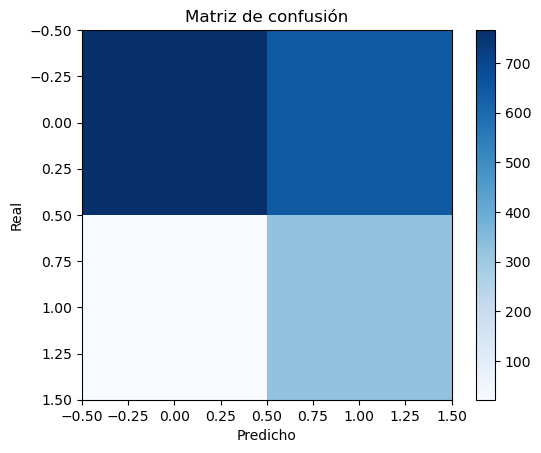

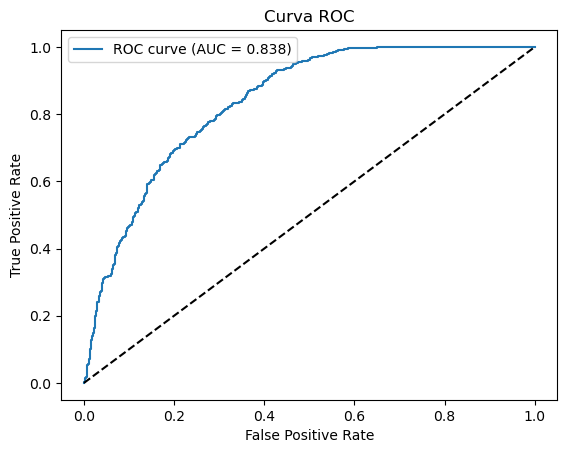

✅ Modelo y scaler guardados correctamente.


c:\Users\M650C\anaconda3\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [6]:
# ==========================
# 8. ENTRENAMIENTO CON BALANCEO Y AUGMENTACIÓN
# ==========================
from sklearn.utils import resample
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence

# -------------------------
# 8.1 Balanceo de clases (undersampling de benignos)
# -------------------------
X_train_mal = X_train[y_train == 1]
y_train_mal = y_train[y_train == 1]
X_train_ben = X_train[y_train == 0]
y_train_ben = y_train[y_train == 0]

# Reducir benignos al número de malignos
X_train_ben_down, y_train_ben_down = resample(
    X_train_ben, y_train_ben,
    replace=False,
    n_samples=len(y_train_mal),
    random_state=RANDOM_STATE
)

# Unir y mezclar
X_train_bal = np.concatenate([X_train_mal, X_train_ben_down])
y_train_bal = np.concatenate([y_train_mal, y_train_ben_down])
indices = np.arange(len(y_train_bal))
np.random.shuffle(indices)
X_train_bal = X_train_bal[indices]
y_train_bal = y_train_bal[indices]

# -------------------------
# 8.2 Data augmentation ligera
# -------------------------
datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# -------------------------
# 8.3 Generador personalizado para múltiples inputs
# -------------------------
class HybridDataGenerator(Sequence):
    def __init__(self, images, abcde_features, labels, batch_size, augmentor=None, shuffle=True):
        self.images = images
        self.abcde = abcde_features
        self.labels = labels
        self.batch_size = batch_size
        self.augmentor = augmentor
        self.shuffle = shuffle
        self.indices = np.arange(len(self.labels))
        self.on_epoch_end()
        
    def __len__(self):
        return int(np.ceil(len(self.labels) / self.batch_size))
    
    def __getitem__(self, index):
        batch_idx = self.indices[index*self.batch_size : (index+1)*self.batch_size]
        X_img = self.images[batch_idx]
        X_abcde = self.abcde[batch_idx]
        y = self.labels[batch_idx]
        
        if self.augmentor:
            X_img_aug = np.empty_like(X_img)
            for i in range(len(X_img)):
                X_img_aug[i] = self.augmentor.random_transform(X_img[i])
            X_img = X_img_aug
        
        return {"image_input": X_img, "abcde_input": X_abcde}, y
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# -------------------------
# Creamos el generador
# -------------------------
train_gen = HybridDataGenerator(
    X_train_bal, ABCDE_train_s[indices], y_train_bal,
    batch_size=BATCH_SIZE,
    augmentor=datagen,
    shuffle=True
)

# -------------------------
# 8.4 Entrenamiento usando el generador
# -------------------------
history = model.fit(
    train_gen,
    validation_data=({"image_input": X_val, "abcde_input": ABCDE_val_s}, y_val),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# ==========================
# 9. EVALUACIÓN CON THRESHOLD AJUSTADO
# ==========================
y_pred_prob = model.predict({"image_input": X_test, "abcde_input": ABCDE_test_s})

# Ajustar threshold para mejorar recall en malignos
threshold = 0.4
y_pred = (y_pred_prob > threshold).astype(int)

print("\n📊 Reporte de clasificación (threshold=0.4):")
print(classification_report(y_test, y_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.colorbar()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

# -------------------------
# 10. GUARDADO FINAL
# -------------------------
joblib.dump(scaler, "abcde_scaler.pkl")
model.save("hybrid_model_final.h5")
print("✅ Modelo y scaler guardados correctamente.")




📊 Reporte de clasificación (threshold=0.4):
              precision    recall  f1-score   support

           0     0.9721    0.5425    0.6964      1412
           1     0.3340    0.9364    0.4924       346

    accuracy                         0.6200      1758
   macro avg     0.6531    0.7395    0.5944      1758
weighted avg     0.8465    0.6200    0.6562      1758

ROC AUC: 0.8380520394963074


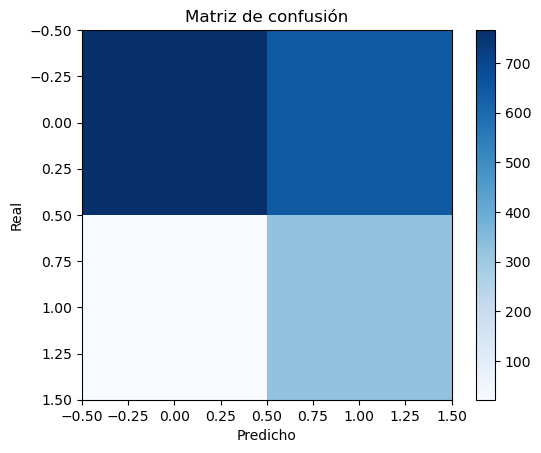

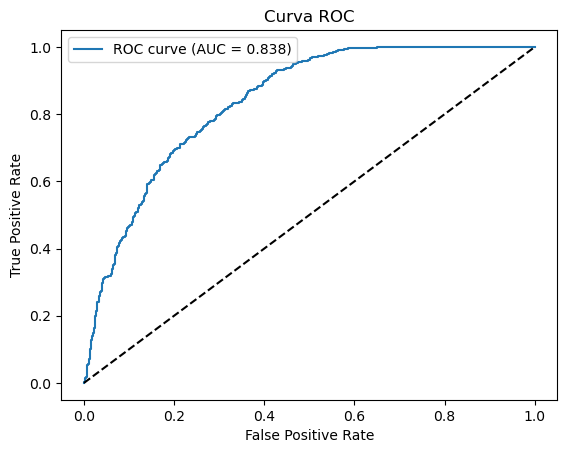

✅ Modelo y scaler guardados correctamente.


c:\Users\M650C\anaconda3\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [7]:
print("\n📊 Reporte de clasificación (threshold=0.4):")
print(classification_report(y_test, y_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.colorbar()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

# -------------------------
# 10. GUARDADO FINAL
# -------------------------
joblib.dump(scaler, "abcde_scaler.pkl")
model.save("hybrid_model_final.h5")
print("✅ Modelo y scaler guardados correctamente.")

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image_input (InputLayer)    [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 cnn_improved (Functional)   (None, 256)                  320928    ['image_input[0][0]']         
                                                                                                  
 abcde_input (InputLayer)    [(None, 5)]                  0         []                            
                                                                                                  
 concatenate_1 (Concatenate  (None, 261)                  0         ['cnn_improved[0][0]',        
 )                                                                   'abcde_input[0][0]']   

c:\Users\M650C\anaconda3\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


101/101 [==============================] - ETA: 0s - loss: 0.8081 - accuracy: 0.5012 - AUC: 0.5001
Epoch 2: val_AUC improved from 0.47565 to 0.48093, saving model to hybrid_model_best.h5
101/101 [==============================] - 79s 786ms/step - loss: 0.8081 - accuracy: 0.5012 - AUC: 0.5001 - val_loss: 0.8040 - val_accuracy: 0.1967 - val_AUC: 0.4809 - lr: 1.0000e-04
Epoch 3/40
101/101 [==============================] - ETA: 0s - loss: 0.8041 - accuracy: 0.5003 - AUC: 0.5017
Epoch 3: val_AUC did not improve from 0.48093
101/101 [==============================] - 79s 778ms/step - loss: 0.8041 - accuracy: 0.5003 - AUC: 0.5017 - val_loss: 0.7973 - val_accuracy: 0.1956 - val_AUC: 0.4683 - lr: 1.0000e-04
Epoch 4/40
101/101 [==============================] - ETA: 0s - loss: 0.8057 - accuracy: 0.4994 - AUC: 0.4868
Epoch 4: val_AUC did not improve from 0.48093
101/101 [==============================] - 78s 773ms/step - loss: 0.8057 - accuracy: 0.4994 - AUC: 0.4868 - val_loss: 0.9053 - val_accu

c:\Users\M650C\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\M650C\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\M650C\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


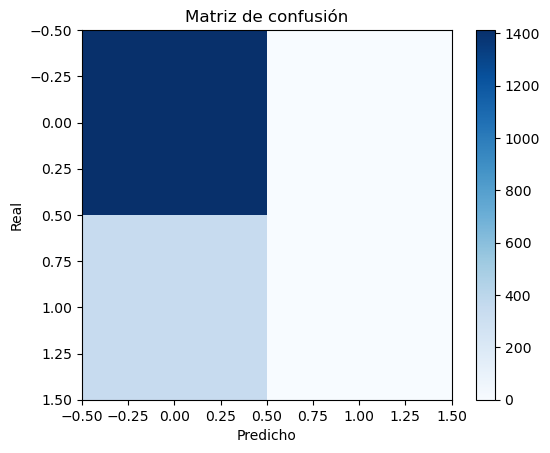

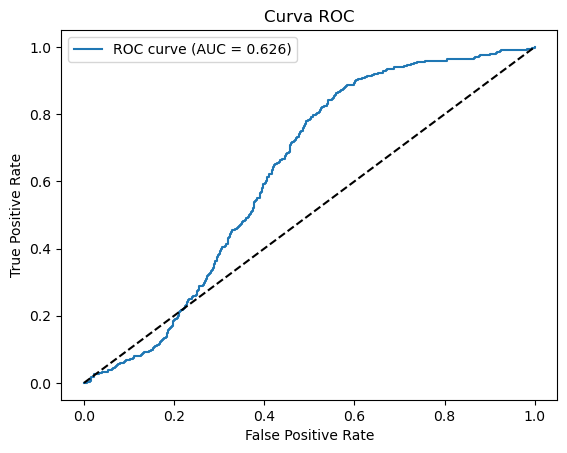

✅ Modelo y scaler guardados correctamente.


c:\Users\M650C\anaconda3\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [10]:
# ==========================
# 6. MODELO CNN + ABCDE MEJORADO
# ==========================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# -------------------------
# CNN mejorada
# -------------------------
def build_cnn_improved(input_shape=(128,128,3)):
    inp = Input(shape=input_shape)
    
    x = Conv2D(32, (3,3), padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = MaxPooling2D(2)(x)
    x = Dropout(0.25)(x)

    x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = MaxPooling2D(2)(x)
    x = Dropout(0.25)(x)

    x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = MaxPooling2D(2)(x)
    x = Dropout(0.3)(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    
    return Model(inp, x, name="cnn_improved")

cnn = build_cnn_improved(IMG_SIZE + (3,))

# -------------------------
# Entrada híbrida CNN + ABCDE
# -------------------------
img_input = Input(shape=IMG_SIZE + (3,), name="image_input")
abcde_input = Input(shape=(ABCDE_train_s.shape[1],), name="abcde_input")
cnn_features = cnn(img_input)
x = concatenate([cnn_features, abcde_input])
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)

model = Model([img_input, abcde_input], out)
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='AUC')])
model.summary()

# ==========================
# 7. CLASS WEIGHTING
# ==========================
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
print("Pesos de clase:", class_weights)

# ==========================
# 8. ENTRENAMIENTO CON BALANCEO Y AUGMENTACIÓN MEJORADA
# ==========================
from sklearn.utils import resample
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence

# -------------------------
# 8.1 Balanceo de clases
# -------------------------
X_train_mal = X_train[y_train == 1]
y_train_mal = y_train[y_train == 1]
X_train_ben = X_train[y_train == 0]
y_train_ben = y_train[y_train == 0]

# Reducir benignos al número de malignos
X_train_ben_down, y_train_ben_down = resample(
    X_train_ben, y_train_ben,
    replace=False,
    n_samples=len(y_train_mal),
    random_state=RANDOM_STATE
)

# Unir y mezclar
X_train_bal = np.concatenate([X_train_mal, X_train_ben_down])
y_train_bal = np.concatenate([y_train_mal, y_train_ben_down])
indices = np.arange(len(y_train_bal))
np.random.shuffle(indices)
X_train_bal = X_train_bal[indices]
y_train_bal = y_train_bal[indices]

# -------------------------
# 8.2 Data augmentation mejorada
# -------------------------
datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.8,1.2],
    fill_mode='nearest'
)

# -------------------------
# 8.3 Generador híbrido
# -------------------------
class HybridDataGenerator(Sequence):
    def __init__(self, images, abcde_features, labels, batch_size, augmentor=None, shuffle=True):
        self.images = images
        self.abcde = abcde_features
        self.labels = labels
        self.batch_size = batch_size
        self.augmentor = augmentor
        self.shuffle = shuffle
        self.indices = np.arange(len(self.labels))
        self.on_epoch_end()
        
    def __len__(self):
        return int(np.ceil(len(self.labels) / self.batch_size))
    
    def __getitem__(self, index):
        batch_idx = self.indices[index*self.batch_size : (index+1)*self.batch_size]
        X_img = self.images[batch_idx]
        X_abcde = self.abcde[batch_idx]
        y = self.labels[batch_idx]
        
        if self.augmentor:
            X_img_aug = np.empty_like(X_img)
            for i in range(len(X_img)):
                X_img_aug[i] = self.augmentor.random_transform(X_img[i])
            X_img = X_img_aug
        
        return {"image_input": X_img, "abcde_input": X_abcde}, y
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Generador
train_gen = HybridDataGenerator(
    X_train_bal, ABCDE_train_s[indices], y_train_bal,
    batch_size=BATCH_SIZE,
    augmentor=datagen,
    shuffle=True
)

# -------------------------
# 8.4 Callbacks mejorados
# -------------------------
callbacks = [
    EarlyStopping(monitor='val_AUC', patience=6, mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_AUC', factor=0.5, patience=3, mode='max', verbose=1),
    ModelCheckpoint("hybrid_model_best.h5", monitor='val_AUC', save_best_only=True, mode='max', verbose=1)
]

# -------------------------
# 8.5 Entrenamiento
# -------------------------
history = model.fit(
    train_gen,
    validation_data=({"image_input": X_val, "abcde_input": ABCDE_val_s}, y_val),
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# ==========================
# 9. EVALUACIÓN CON THRESHOLD AJUSTADO
# ==========================
y_pred_prob = model.predict({"image_input": X_test, "abcde_input": ABCDE_test_s})
threshold = 0.48  # Threshold óptimo por Youden
y_pred = (y_pred_prob > threshold).astype(int)

print("\n📊 Reporte de clasificación (threshold óptimo):")
print(classification_report(y_test, y_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.colorbar()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

# -------------------------
# 10. GUARDADO FINAL
# -------------------------
joblib.dump(scaler, "abcde_scaler.pkl")
model.save("hybrid_model_final.h5")
print("✅ Modelo y scaler guardados correctamente.")


✅ Matriz de confusión (counts):


,Predicho 0,Predicho 1
Benigno (0),766,646
Maligno (1),22,324



✅ Matriz de confusión (porcentajes por fila):


,Predicho 0,Predicho 1
Benigno (0),0.542493,0.457507
Maligno (1),0.063584,0.936416


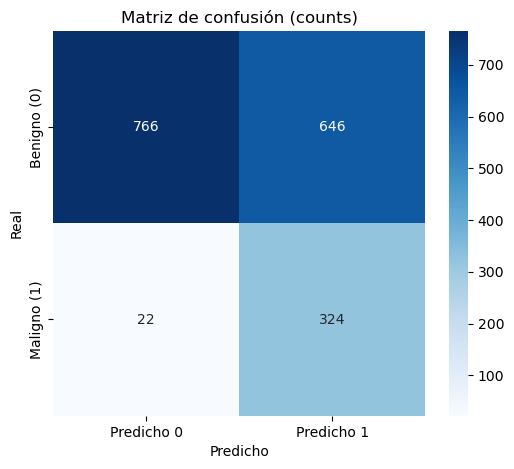

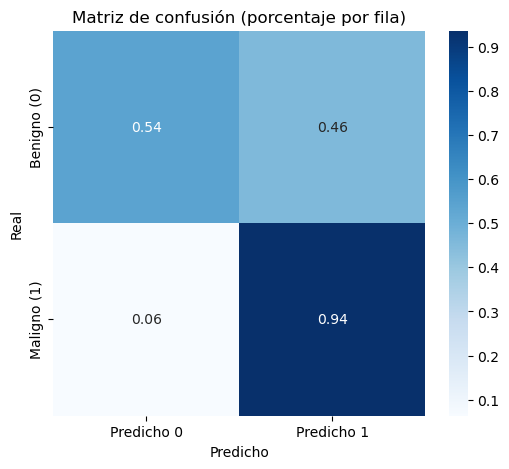

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear DataFrame para mostrar counts
cm_df = pd.DataFrame(cm, index=["Benigno (0)", "Maligno (1)"], columns=["Predicho 0", "Predicho 1"])
cm_df_perc = cm_df / cm_df.sum(axis=1).values[:, None]  # normalizar por fila para porcentajes

print("✅ Matriz de confusión (counts):")
display(cm_df)

print("\n✅ Matriz de confusión (porcentajes por fila):")
display(cm_df_perc)

# Heatmap opcional
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de confusión (counts)")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(cm_df_perc, annot=True, fmt='.2f', cmap='Blues')
plt.title("Matriz de confusión (porcentaje por fila)")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()


✅ Threshold óptimo según Youden: 0.480

📊 Reporte de clasificación (threshold óptimo):
              precision    recall  f1-score   support

           0     0.9520    0.6324    0.7600      1412
           1     0.3671    0.8699    0.5163       346

    accuracy                         0.6792      1758
   macro avg     0.6595    0.7512    0.6381      1758
weighted avg     0.8369    0.6792    0.7120      1758


✅ Matriz de confusión (counts):
[[893 519]
 [ 45 301]]

✅ Matriz de confusión (porcentajes por fila):
[[0.632 0.368]
 [0.13  0.87 ]]


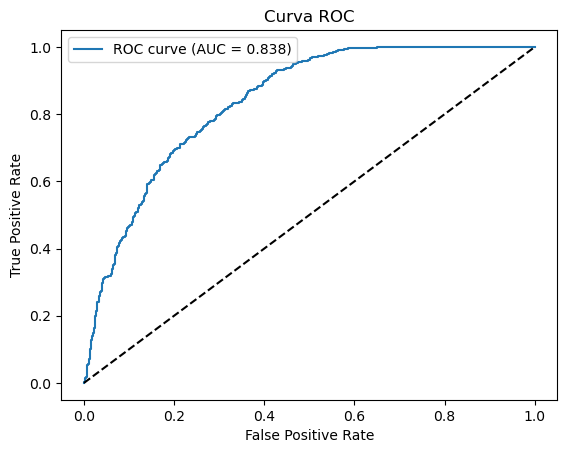

In [9]:
from sklearn.metrics import roc_curve

# -------------------------
# Calcular ROC
# -------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Índice de Youden: max(TPR - FPR)
youden_index = tpr - fpr
best_idx = np.argmax(youden_index)
best_threshold = thresholds[best_idx]

print(f"✅ Threshold óptimo según Youden: {best_threshold:.3f}")

# -------------------------
# Predecir usando threshold óptimo
# -------------------------
y_pred_opt = (y_pred_prob > best_threshold).astype(int)

# Reporte de clasificación
print("\n📊 Reporte de clasificación (threshold óptimo):")
print(classification_report(y_test, y_pred_opt, digits=4))

# Matriz de confusión
cm_opt = confusion_matrix(y_test, y_pred_opt)
cm_percent = cm_opt.astype(float) / cm_opt.sum(axis=1)[:, np.newaxis]

print("\n✅ Matriz de confusión (counts):")
print(cm_opt)
print("\n✅ Matriz de confusión (porcentajes por fila):")
print(np.round(cm_percent, 3))

# Curva ROC
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()




In [ ]:
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=(0.8, 1.2)
)

X_train_aug, y_train_aug = [], []

for x, label in zip(X_train, y_train):
    X_train_aug.append(x)
    y_train_aug.append(label)
    if label == 1:  # solo Malignant
        for _ in range(3):
            X_train_aug.append(datagen.random_transform(x))
            y_train_aug.append(label)

X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)
print("✅ Dataset aumentado:", X_train_aug.shape, y_train_aug.shape)


In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1],3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 128)       0

In [6]:
batch_size = 32
train_gen = generator(df_train, ZIP_PATH, batch_size=batch_size)

steps_per_epoch = len(df_train)//batch_size
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
289/289 [==============================] - 80s 273ms/step - loss: 0.6399 - accuracy: 0.5358
Epoch 2/20
289/289 [==============================] - 79s 274ms/step - loss: 0.5791 - accuracy: 0.5233
Epoch 3/20
289/289 [==============================] - 78s 270ms/step - loss: 0.5532 - accuracy: 0.5631
Epoch 4/20
289/289 [==============================] - 84s 291ms/step - loss: 0.6438 - accuracy: 0.3221
Epoch 5/20
289/289 [==============================] - 80s 277ms/step - loss: 0.5999 - accuracy: 0.6082
Epoch 6/20
289/289 [==============================] - 79s 273ms/step - loss: 0.5257 - accuracy: 0.6011
Epoch 7/20
289/289 [==============================] - 79s 273ms/step - loss: 0.5455 - accuracy: 0.6150
Epoch 8/20
289/289 [==============================] - 78s 269ms/step - loss: 0.5030 - accuracy: 0.6665
Epoch 9/20
289/289 [==============================] - 80s 277ms/step - loss: 0.4771 - accuracy: 0.7019
Epoch 10/20
289/289 [==============================] - 80s 278ms/step - l

73/73 [==============================] - 3s 44ms/step - loss: 0.4913 - accuracy: 0.7788
📊 Test accuracy: 0.7788
73/73 [==============================] - 3s 44ms/step


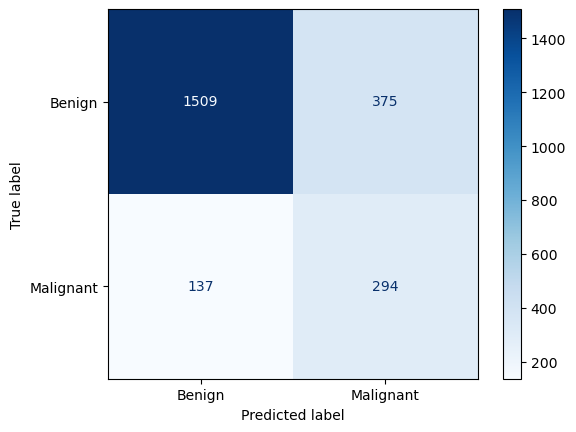

              precision    recall  f1-score   support

      Benign       0.92      0.80      0.85      1884
   Malignant       0.44      0.68      0.53       431

    accuracy                           0.78      2315
   macro avg       0.68      0.74      0.69      2315
weighted avg       0.83      0.78      0.80      2315



In [7]:
# Cargar todas las imágenes de test (si tu RAM lo permite)
X_test_list, y_test_list = [], []
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    for _, row in df_test.iterrows():
        try:
            img = load_image_from_zip(zip_ref, row['isic_id']+'.jpg', size=IMG_SIZE)
            X_test_list.append(img)
            y_test_list.append(1 if row['diagnosis_1']=='Malignant' else 0)
        except KeyError:
            continue

X_test = np.array(X_test_list)
y_test = np.array(y_test_list)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"📊 Test accuracy: {test_acc:.4f}")

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob>0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign","Malignant"])
disp.plot(cmap="Blues")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Benign","Malignant"]))
